<a href="https://colab.research.google.com/github/AliSalman25/first-Jupyter-Notebook-for-the-experiments/blob/main/F1rstPaper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

            Price
Date             
2003-01-02  30.05
2003-01-03  30.83
2003-01-06  30.71
2003-01-07  29.72
2003-01-08  28.86


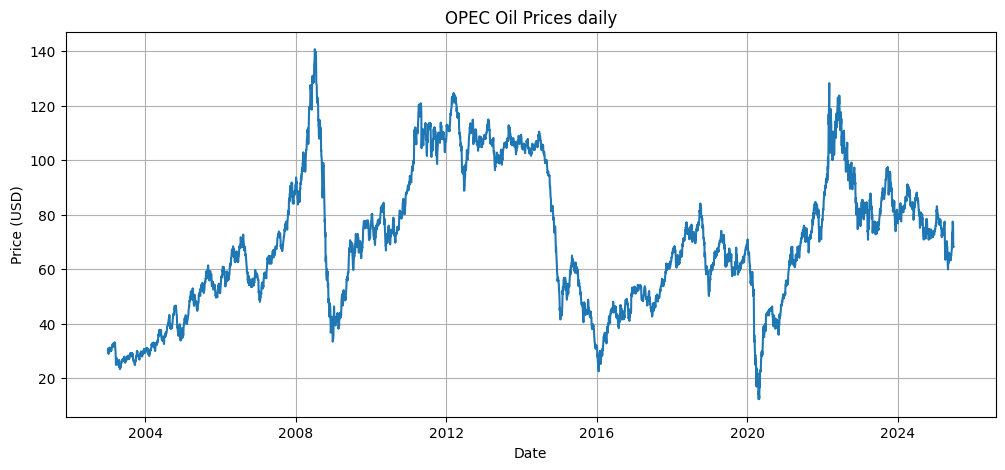

In [ ]:
# الخطوة 1: استيراد المكتبات
import pandas as pd
import matplotlib.pyplot as plt

# تحميل البيانات
file_path = '/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv'
df = pd.read_csv(file_path)

# تحويل العمود Date إلى نوع تاريخي
df['Date'] = pd.to_datetime(df['Date'])

# ضبط التاريخ كمؤشر للبيانات
df.set_index('Date', inplace=True)

# عرض أول خمس صفوف
print(df.head())

# رسم السلسلة الزمنية
plt.figure(figsize=(12,5))
plt.plot(df['Price'])
plt.title('OPEC Oil Prices daily')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()


In [ ]:
# الخطوة 2: التحقق من الثبات باستخدام اختبار ADF
from statsmodels.tsa.stattools import adfuller

# تنفيذ الاختبار
result = adfuller(df['Price'])

# عرض النتائج
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Used Lags:', result[2])
print('Number of Observations:', result[3])
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')


ADF Statistic: -2.969114269366679
p-value: 0.037881148719252675
Used Lags: 32
Number of Observations: 5766
Critical Values:
   1%: -3.4314846190761017
   5%: -2.862041393601955
   10%: -2.5670368899004763


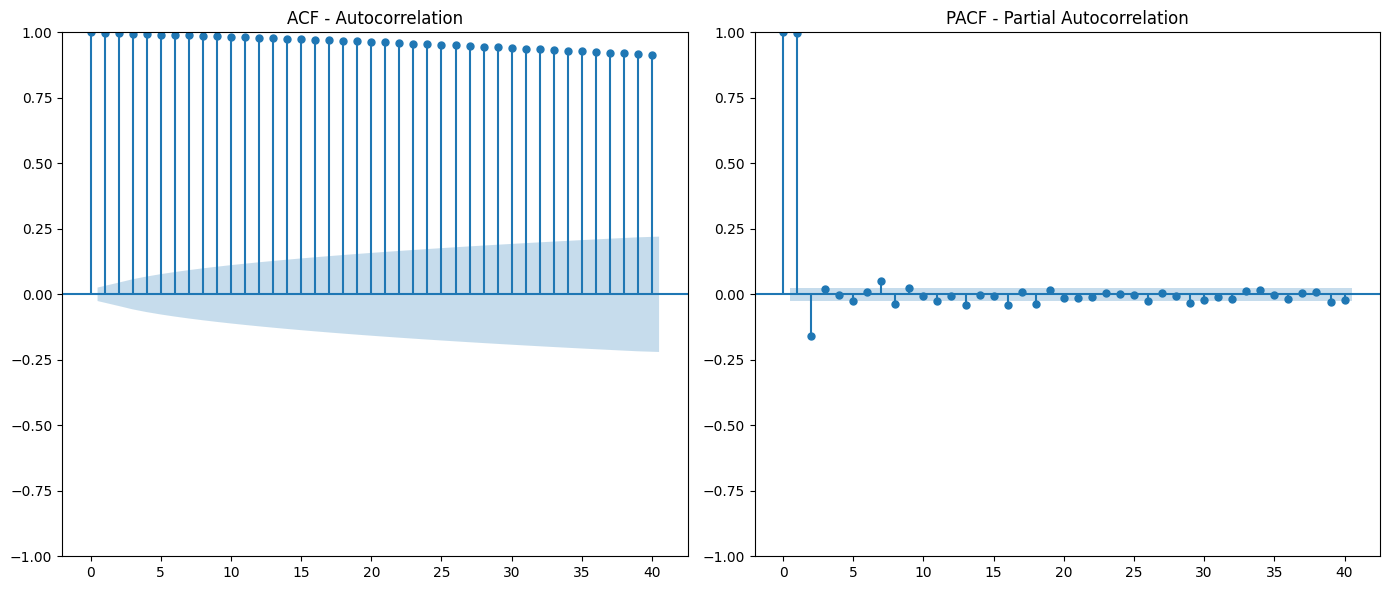

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# إذا كانت السلسلة الأصلية ثابتة كما أثبت اختبار ADF، نستخدمها كما هي
plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
plot_acf(df['Price'], lags=40, ax=plt.gca())
plt.title('ACF - Autocorrelation')

plt.subplot(1, 2, 2)
plot_pacf(df['Price'], lags=40, ax=plt.gca(), method='ywm')
plt.title('PACF - Partial Autocorrelation')

plt.tight_layout()
plt.show()


In [ ]:
# حجم التدريب
train_size = int(len(df) * 0.8)

# تقسيم السلسلة الزمنية
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(f"Train size: {len(train)}, Test size: {len(test)}")


Train size: 4639, Test size: 1160


In [ ]:
!pip install statsmodels


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(1, 0, 1))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -6774.988
Date:                Wed, 30 Jul 2025   AIC                          13557.976
Time:                        10:33:12   BIC                          13583.745
Sample:                             0   HQIC                         13567.042
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4878     11.329      5.957      0.000      45.283      89.692
ar.L1          0.9987      0.001   1674.067      0.000       0.998       1.000
ma.L1          0.2485      0.009     28.667      0.0

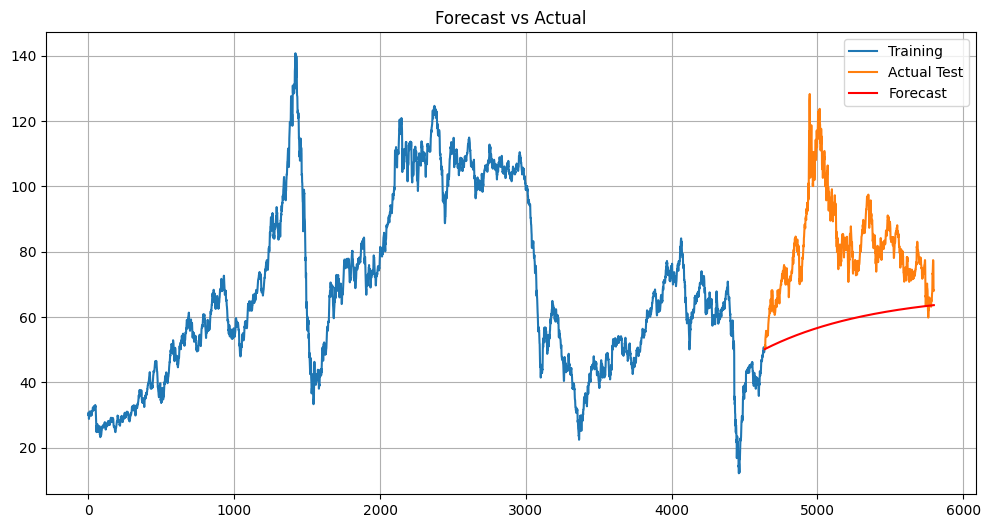

In [ ]:
# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')


MAE: 23.3816
RMSE: 27.1457


(1, 0, 0)

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -6913.487
Date:                Wed, 30 Jul 2025   AIC                          13832.975
Time:                        11:07:03   BIC                          13852.301
Sample:                             0   HQIC                         13839.774
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4876     11.823      5.708      0.000      44.315      90.660
ar.L1          0.9991      0.000   2062.902      0.000       0.998       1.000
sigma2         1.1518      0.010    115.447      0.0

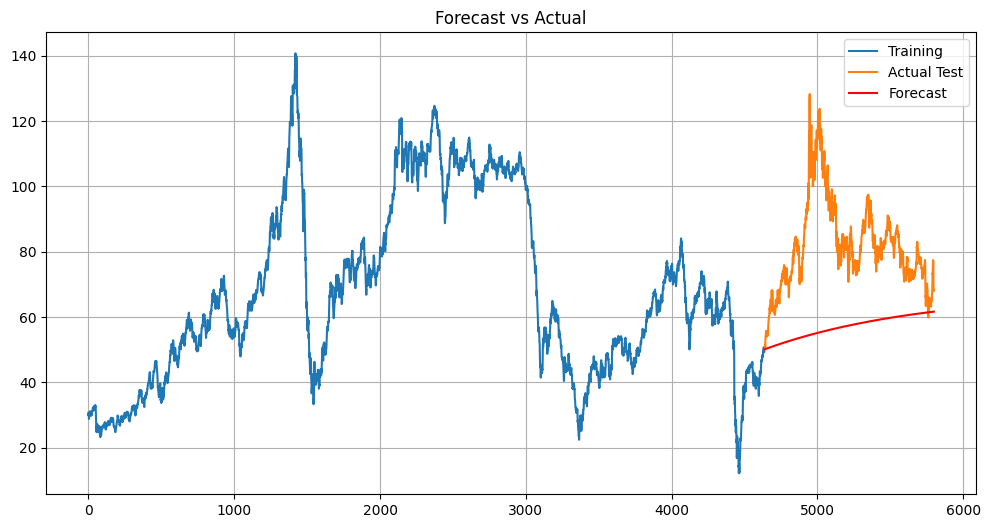

MAE: 24.9789
RMSE: 28.5601


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(1, 0, 0))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')




2,0,1

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(2, 0, 1)   Log Likelihood               -6774.967
Date:                Wed, 30 Jul 2025   AIC                          13559.933
Time:                        11:07:50   BIC                          13592.145
Sample:                             0   HQIC                         13571.266
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4874     11.910      5.667      0.000      44.145      90.830
ar.L1          0.9944      0.042     23.789      0.000       0.912       1.076
ar.L2          0.0044      0.042      0.104      0.9

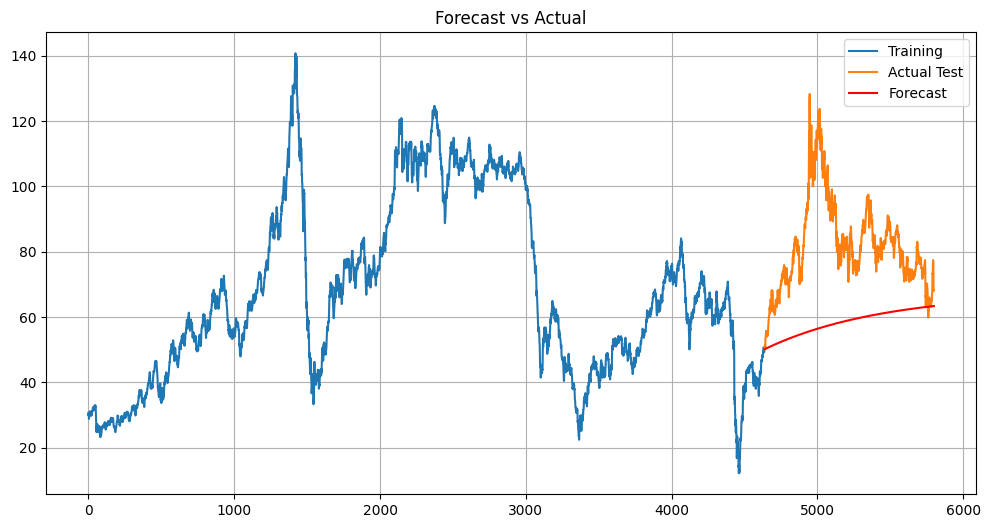

MAE: 23.6208
RMSE: 27.3593


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(2, 0, 1))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')




                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -6774.995
Date:                Wed, 30 Jul 2025   AIC                          13559.990
Time:                        12:44:13   BIC                          13592.202
Sample:                             0   HQIC                         13571.323
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4878     11.230      6.010      0.000      45.478      89.498
ar.L1          0.9987      0.001   1675.639      0.000       0.998       1.000
ma.L1          0.2485      0.009     28.337      0.0

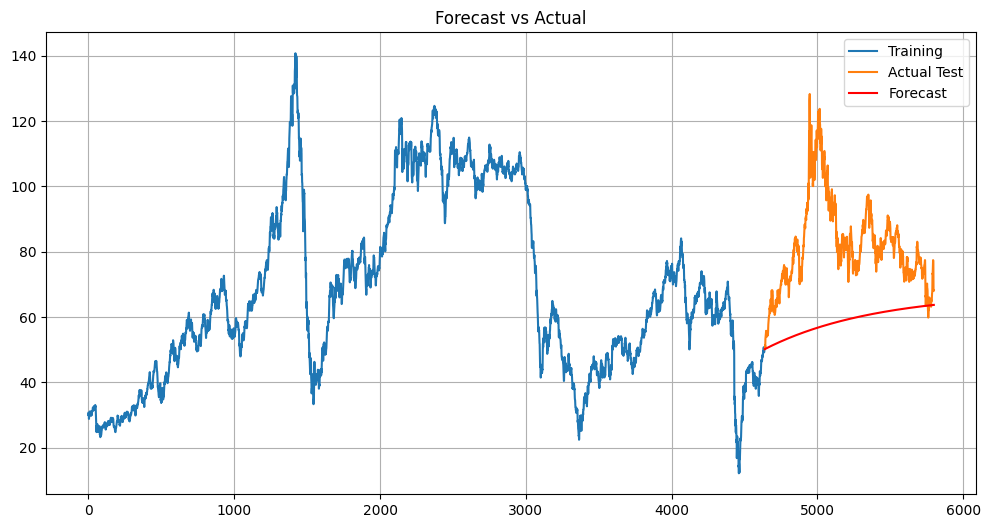

MAE: 23.3186
RMSE: 27.0892


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(1, 0, 2))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')




/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -6773.069
Date:                Wed, 30 Jul 2025   AIC                          13558.138
Time:                        11:19:16   BIC                          13596.791
Sample:                             0   HQIC                         13571.737
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.1446     13.446      4.919      0.000      39.792      92.497
ar.L1          0.2014      0.138      1.464      0.143      -0.068       0.471
ar.L2          0.7966      0.137      5.798      0.0

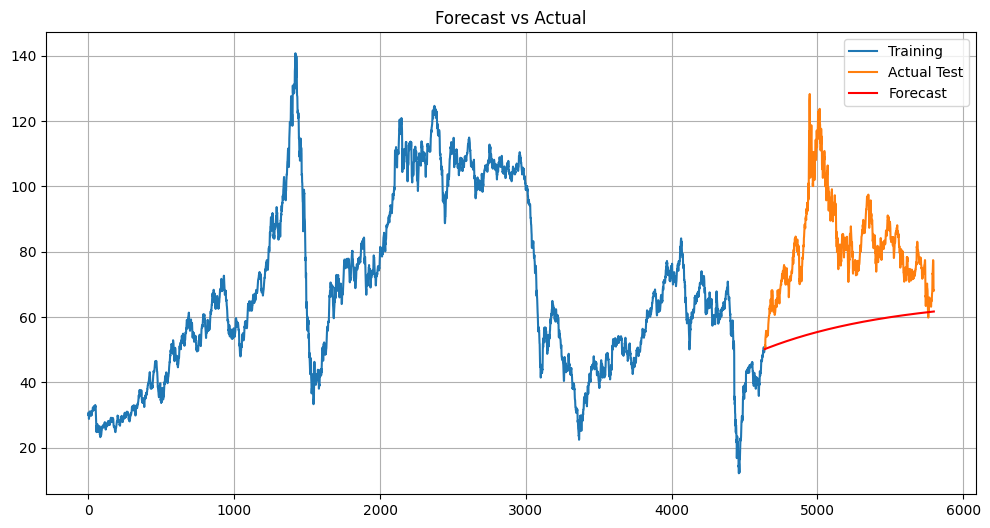

MAE: 24.7738
RMSE: 28.3534


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(2, 0, 2))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')




                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(3, 0, 1)   Log Likelihood               -6773.075
Date:                Wed, 30 Jul 2025   AIC                          13558.150
Time:                        11:23:52   BIC                          13596.804
Sample:                             0   HQIC                         13571.749
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4768     21.754      3.102      0.002      24.840     110.114
ar.L1          0.5249      0.074      7.048      0.000       0.379       0.671
ar.L2          0.5977      0.097      6.175      0.0

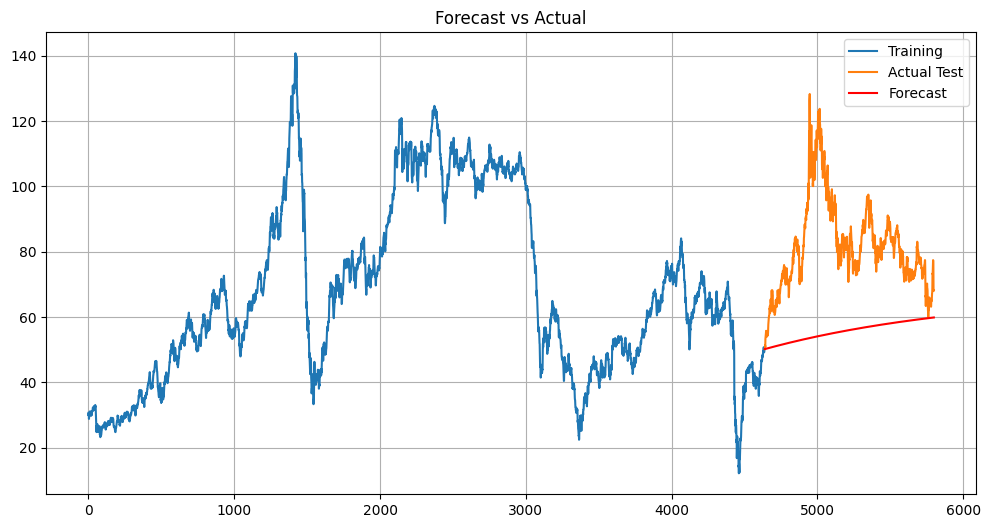

MAE: 26.2242
RMSE: 29.6474


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(3, 0, 1))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')


